# Step 2 - UNet Training

In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import torch.nn.functional as F
import math

In [3]:
device = "mps"

# DOWN BELOW IS COPIED FROM THE 1st NOTEBOOK!

# Number of time steps
T = 1000

# Variance (!) of the noise getting added in each step
betas = torch.linspace(1e-4,0.02,T, device=device)

# Complements of noises, how much signal survives in each step
alphas = 1 - betas

# Cumulative products of alphas. entry t is the a_1 \cdot \dots \cdot a_t
# How much of the original image survives after t steps
alpha_bars = torch.cumprod(alphas, dim=0)

In [4]:
# DOWN BELOW IS COPIED FROM THE 1st NOTEBOOK!

def q_sample(x_0, t):
    # 1. draw the noise                          -> (B, 1, 32, 32)
    eps = torch.randn(x_0.shape, dtype=x_0.dtype, device=x_0.device)

    # 2. look up alpha_bar for each t in the batch  -> (B,)
    ab = alpha_bars[t]

    # 3. reshape so it broadcasts over images     -> (B, 1, 1, 1)
    ab = ab.view(x_0.shape[0], 1, 1, 1)
    # OR I could have said 'ab = ab.view(-1, 1, 1, 1)' instead. This is also a shorter notation apparently

    # 4. the closed form
    x_t = ab.sqrt() * x_0 + (1-ab).sqrt()* eps

    return x_t, eps


In [5]:
# DOWN BELOW IS COPIED FROM THE 1st NOTEBOOK!

tf = transforms.Compose([
    transforms.ToTensor(),                 # PIL uint8 [0,255] HWC -> float32 [0,1] CHW, (1,28,28)
    transforms.Pad(2),                     # -> (1,32,32); fill=0 is black, matches background
    transforms.Normalize((0.5,), (0.5,)),  # (x - 0.5) / 0.5  ->  [-1,1]
])

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=tf)

In [6]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

# Let's verify

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(images.to(device).device)

torch.Size([128, 1, 32, 32])
torch.Size([128])
mps:0


In [7]:
class StubModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )
    def forward(self, x, t):
        return self.net(x)

In [7]:
# Initialize a StubModel instance
model = StubModel().to(device)

# Create the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [8]:
batch_size = 128

stub_losses = []

for epoch in range(2):
    for images, _ in train_loader:
        x_0 = images.to(device)             # move images to the device
        t   = torch.randint(0, T, (x_0.shape[0],), device=device)           # random timesteps, one per image
        x_t, eps = q_sample(x_0, t)         # q_sample
        pred = model(x_t, t)         # the model's guess
        loss = F.mse_loss(pred, eps)            # mse against eps

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        stub_losses.append(loss.item())


In [9]:
print("First 5 losses:")
print(stub_losses[:5])

print("Last 5 losses:")
print(stub_losses[-5:])

First 5 losses:
[0.9852547645568848, 0.9791358709335327, 0.9640768766403198, 0.9502594470977783, 0.9447487592697144]
Last 5 losses:
[0.12517718970775604, 0.14995720982551575, 0.14805088937282562, 0.1667395681142807, 0.10408151149749756]


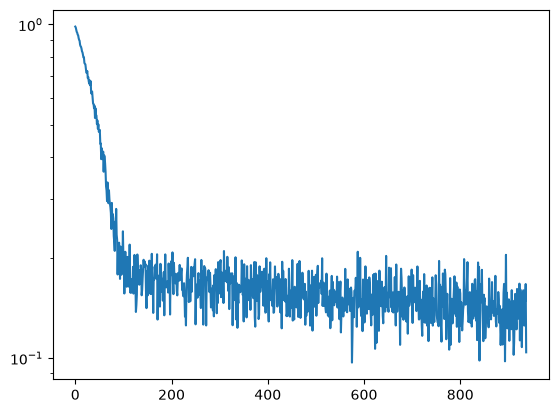

In [10]:
# Let's visually see how our losses look like for 2 epoch with only using our first approach.
plt.yscale("log")
plt.plot(stub_losses)

In [8]:
def timestep_embedding(t, dim):
    # t: (B,) integer timesteps  ->  (B, dim) float
    half = dim // 2
    # (half,)  geometric, 1 down to 1/10000
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    # (B, half)
    args = t[:, None] * freqs[None, :]
    # (B, dim)
    return torch.cat([args.sin(), args.cos()], dim=1)


In [9]:
# Let's check and verify

t = torch.arange(1000, device=device)
# (1000, 64)
e = timestep_embedding(t, 64)
n = e / e.norm(dim=1, keepdim=True)

# Check the similarity here
sim = n @ n.T

# Check for some values comparing to 500 for similarities
for tv in [499, 500, 501, 510, 600, 900]:
    print(tv, sim[500, tv].item())


499 0.9661511182785034
500 1.000000238418579
501 0.9661509394645691
510 0.6578636169433594
600 0.5585835576057434
900 0.24231550097465515


In [10]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, temb_dim):
        super().__init__()
        # GroupNorm, 8 groups, over in_ch
        self.norm1 = nn.GroupNorm(num_groups=8, num_channels=in_ch)
        # 3x3, in_ch -> out_ch, padding 1
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        # Linear, temb_dim -> out_ch
        self.time_proj = nn.Linear(temb_dim, out_ch)
        # GroupNorm, 8 groups, over out_ch
        self.norm2 = nn.GroupNorm(num_groups=8, num_channels=out_ch)
        # 3x3, out_ch -> out_ch, padding 1
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # 1x1 conv if channels change, else nn.Identity()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, temb):
        # conv1( silu( norm1(x) ) )
        h = self.conv1(F.silu(self.norm1(x)))
        # h + time_proj( silu(temb) ) reshaped to (B, out_ch, 1, 1)
        h = h + self.time_proj(F.silu(temb))[:, :, None, None]
        # conv2( silu( norm2(h) ) )
        h = self.conv2(F.silu(self.norm2(h)))
        # h + skip(x)
        return h + self.skip(x)


In [11]:
# Let's test
b1 = ResBlock(32, 64, 128).to(device)
b2 = ResBlock(64, 64, 128).to(device)
x = torch.randn(4, 32, 32, 32, device=device)
temb = torch.randn(4, 128, device=device)

print(b1(x, temb).shape)
print(b2(b1(x, temb), temb).shape)

torch.Size([4, 64, 32, 32])
torch.Size([4, 64, 32, 32])


In [12]:
# Let's go for UNet, which is the keystone and the action will happen

class UNet(nn.Module):
    def __init__(self, in_ch=1, base=64, temb_dim=256):
        super().__init__()
        # forward needs this to call timestep_embedding
        self.temb_dim = temb_dim

        # Linear -> SiLU -> Linear, all temb_dim
        self.temb_mlp = nn.Sequential(
            nn.Linear(self.temb_dim, self.temb_dim),
            nn.SiLU(),
            nn.Linear(self.temb_dim, self.temb_dim)
        )

        # conv 1 -> 64
        self.stem = nn.Conv2d(in_ch, base, 3, padding=1)

        # ResBlocks @ 32x32
        self.d1a, self.d1b = ResBlock(base, base, temb_dim), ResBlock(base, base, temb_dim)

        # stride-2 conv, 64 -> 64
        self.down1 = nn.Conv2d(base, base, kernel_size=3, stride=2, padding=1)

        # ResBlocks @ 16x16
        self.d2a, self.d2b = ResBlock(base, base*2, temb_dim), ResBlock(base*2, base*2, temb_dim)

        # stride-2 conv, 128 -> 128
        self.down2 = nn.Conv2d(base*2, base*2, kernel_size=3, stride=2, padding=1)

        # ResBlock @ 8x8
        self.mid = ResBlock(base*2, base*2, temb_dim)

        # Upsample + conv, -> 16x16
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(base*2, base*2, kernel_size=3, padding=1)
        )

        # ResBlocks after concat (in_ch = 256)
        self.u1a, self.u1b = ResBlock(base*4, base*2, temb_dim), ResBlock(base*2, base*2, temb_dim)

        # Upsample + conv, -> 32x32
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(base*2, base*2, kernel_size=3, padding=1)
        )

        # ResBlocks after concat (in_ch = 192)
        self.u2a, self.u2b = ResBlock(base*3, base, temb_dim), ResBlock(base, base, temb_dim)

        # GroupNorm(8, 64)
        self.out_norm = nn.GroupNorm(8, base)

        # conv 64 -> 1
        self.out_conv = nn.Conv2d(base, in_ch, kernel_size=3, padding=1)

    def forward(self, x, t):
        # timestep_embedding -> temb_mlp, ONCE
        temb = self.temb_mlp(timestep_embedding(t, self.temb_dim))

        # stem
        h = self.stem(x)

        # d1a
        h = self.d1a(h, temb)
        # d1b
        h = self.d1b(h, temb)
        
        # stash
        A = h

        # down1
        h = self.down1(h)

        # d2a
        h = self.d2a(h, temb)
        # d2b
        h = self.d2b(h, temb)
        
        # stash
        B = h

        # down2
        h = self.down2(h)
        
        # mid
        h = self.mid(h, temb)

        # up1
        h = self.up1(h)
        
        # cat with B
        h = torch.cat([h, B], dim=1)

        # u1a
        h = self.u1a(h, temb)
        # u1b
        h = self.u1b(h, temb)

        # up2
        h = self.up2(h)
        
        # cat with A
        h = torch.cat([h, A], dim=1)

        # u2a
        h = self.u2a(h, temb)
        
        # u2b
        h = self.u2b(h, temb)

        # out_conv(silu(out_norm(h)))
        return self.out_conv(F.silu(self.out_norm(h)))



In [13]:
# Let's check for the first time
m = UNet()
print(m)
print(sum(p.numel() for p in m.parameters()))

UNet(
  (temb_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (stem): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1a): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (d1b): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), s

In [14]:
# Initialize a UNetModel instance
model = UNet().to(device)

# Create the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [21]:
# Let's train for UNet

unet_losses = []

for epoch in range(40):
    for i, (images, _) in enumerate(train_loader):
        # move images to the device
        x_0 = images.to(device)

        # random timesteps, one per image
        t   = torch.randint(0, T, (x_0.shape[0],), device=device)

        # q_sample
        x_t, eps = q_sample(x_0, t)

        # the model's guess
        pred = model(x_t, t)

        # mse against eps
        loss = F.mse_loss(pred, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        unet_losses.append(loss.item())

        if i % 50 == 0:
            print(f"epoch {epoch} batch {i}  loss {loss.item():.4f}")

    # a checkpoint for each epoch
    if epoch % 5 == 0:
        torch.save(model.state_dict(), f"ckpt_{epoch}.pt")



epoch 0 batch 0  loss 1.0400
epoch 0 batch 50  loss 0.0806
epoch 0 batch 100  loss 0.0499
epoch 0 batch 150  loss 0.0420
epoch 0 batch 200  loss 0.0325
epoch 0 batch 250  loss 0.0328
epoch 0 batch 300  loss 0.0317
epoch 0 batch 350  loss 0.0276
epoch 0 batch 400  loss 0.0242
epoch 0 batch 450  loss 0.0266
epoch 1 batch 0  loss 0.0310
epoch 1 batch 50  loss 0.0280
epoch 1 batch 100  loss 0.0265
epoch 1 batch 150  loss 0.0244
epoch 1 batch 200  loss 0.0295
epoch 1 batch 250  loss 0.0275
epoch 1 batch 300  loss 0.0260
epoch 1 batch 350  loss 0.0244
epoch 1 batch 400  loss 0.0290
epoch 1 batch 450  loss 0.0200
epoch 2 batch 0  loss 0.0316
epoch 2 batch 50  loss 0.0235
epoch 2 batch 100  loss 0.0264
epoch 2 batch 150  loss 0.0212
epoch 2 batch 200  loss 0.0232
epoch 2 batch 250  loss 0.0237
epoch 2 batch 300  loss 0.0201
epoch 2 batch 350  loss 0.0258
epoch 2 batch 400  loss 0.0202
epoch 2 batch 450  loss 0.0231
epoch 3 batch 0  loss 0.0228
epoch 3 batch 50  loss 0.0228
epoch 3 batch 100  l

In [16]:
model = UNet().to(device)
print(model.load_state_dict(torch.load("ckpt_35.pt", map_location=device)))
model.eval()

<All keys matched successfully>


UNet(
  (temb_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (stem): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1a): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (d1b): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), s

In [17]:
x_t = torch.randn(4, 1, 32, 32, device=device)
t = torch.randint(0, T, (4,), device=device)
print(model(x_t, t).shape)

torch.Size([4, 1, 32, 32])


# Step 3 - Sampler

In [38]:
# Adding the @torch.no_grad() is crucial here.
@torch.no_grad()
def sample(model, n_samples):
    model.eval()

    # (n, 1, 32, 32) pure noise, on device
    x = torch.randn([n_samples, 1, 32, 32], device=device)

    # 999 down to 0
    for i in reversed(range(T)):
        # (n,) all equal to i, long dtype, on device
        t = torch.full((n_samples,), i, device=device)
        # (n, 1, 32, 32)
        eps_hat = model(x, t)

        # alphas[i]
        a = alphas[i]
        # alpha_bars[i]
        a_bar = alpha_bars[i]
        # betas[i]
        b = betas[i]

        # fresh noise, but zeros when i == 0
        z = torch.randn_like(x) if i != 0 else torch.zeros_like(x)

        # the reverse step
        x = (1 / a.sqrt()) * (x - ((1 - a) / (1 - a_bar).sqrt()) * eps_hat ) + (b.sqrt() * z)

    return x

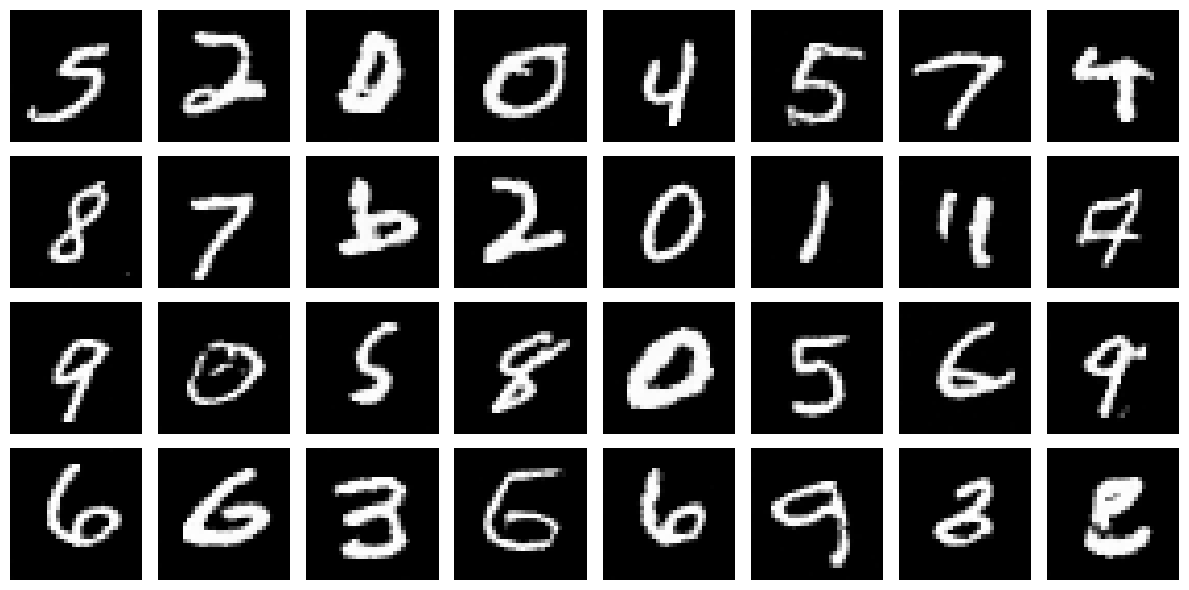

In [ ]:
# Let's see what kind of samples we are able to get via our sampler function

out = sample(model, 32)
out = out.cpu()

fig, axes = plt.subplots(4, 8, figsize=[12,6])

for k in range(32):
    img = out[k].squeeze()
    img = (img + 1) / 2
    axes[k // 8, k % 8].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[k // 8, k % 8].axis("off")

fig.tight_layout()
plt.show()